In [81]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
import json
import emcee
from scipy.special import logsumexp


In [82]:
%matplotlib widget
plt.close('all')

In [83]:
piano_dir = "dati_piano"
piano_files = [f for f in os.listdir(piano_dir) if f.endswith('.wav')]
piano_files.sort()  # Sort files to ensure correct order

print("Available piano files:")
for f in piano_files:
    print(f" - {f}")

Available piano files:
 - Organo 1 - staccato.wav
 - Organo 2 - Legato e staccato mix.wav
 - Piano scala MI - lento.wav
 - Piano scala MI - medio.wav
 - Piano scala MI - veloce staccato.wav
 - Piano scala Mi - veloe legato.wav


In [84]:
waveform_dict = {}
for f in piano_files:
    filepath = os.path.join(piano_dir, f)
    fs, data = readwav(filepath)
    waveform_dict[f] = (fs, data)

print("\nLoaded waveforms:")
for f in piano_files:
    fs, data = waveform_dict[f]
    print(f" - {f}: fs={fs}, length={len(data)} samples")


Loaded waveforms:
 - Organo 1 - staccato.wav: fs=44100, length=851836 samples
 - Organo 2 - Legato e staccato mix.wav: fs=44100, length=917372 samples
 - Piano scala MI - lento.wav: fs=44100, length=1113980 samples
 - Piano scala MI - medio.wav: fs=44100, length=786300 samples
 - Piano scala MI - veloce staccato.wav: fs=44100, length=458620 samples
 - Piano scala Mi - veloe legato.wav: fs=44100, length=393084 samples


In [85]:
def moving_rms(x, window_size):
    """Calculate the moving RMS of a signal."""
    return np.sqrt(np.convolve(x**2, np.ones(window_size)/window_size, mode='valid'))

def secs_to_samples(secs, fs):
    """Convert seconds to samples."""
    return secs * fs

def samples_to_secs(samples, fs):
    """Convert samples to seconds."""
    return samples / fs

In [121]:
def compute_spectral_flux(segment, frame_size, hop_size):
    """Compute the spectral flux of a signal segment."""
    # Compute the magnitude spectrum
    window = np.hanning(frame_size)
    frames = sp.signal.stft(segment, nperseg=frame_size, noverlap=frame_size - hop_size, window=window)[2]
    magnitude_spectrum = np.abs(frames)
    
    # Compute spectral flux
    spectral_flux = np.sqrt(np.sum(np.diff(magnitude_spectrum, axis=1)**2, axis=0))

    inds = np.arange(len(spectral_flux)) * hop_size

    return inds, spectral_flux

def detect_onsets(signal, fs, convolve_window=5, prominence=1000, distance=10):
    """Detect onsets from the signal."""

    frame_size = 1024
    hop_size = 512

    inds, spectral_flux = compute_spectral_flux(signal, frame_size, hop_size)

    smooth_flux = np.convolve(spectral_flux, np.ones(convolve_window)/convolve_window, mode='same')
    flux_peaks, _ = sp.signal.find_peaks(smooth_flux, prominence=prominence, distance=distance)

    return inds[flux_peaks]

def segment_signal(signal, fs, onsets, delta=0.1):
    """Segment the signal based on detected onsets."""
    segments = []
    for i in range(len(onsets) - 1):
        start_time = onsets[i] + secs_to_samples(delta, fs)
        end_time = onsets[i + 1] - secs_to_samples(delta, fs)
        segment = signal[int(start_time):int(end_time)]
        segments.append(segment)
    return segments

Dropdown(description='Select file:', options=('Organo 1 - staccato.wav', 'Organo 2 - Legato e staccato mix.wav…

IntSlider(value=1024, continuous_update=False, description='RMS Window Size:', max=8192, min=256, step=256)

IntSlider(value=10, continuous_update=False, description='Convolve Window:', max=1000, min=1)

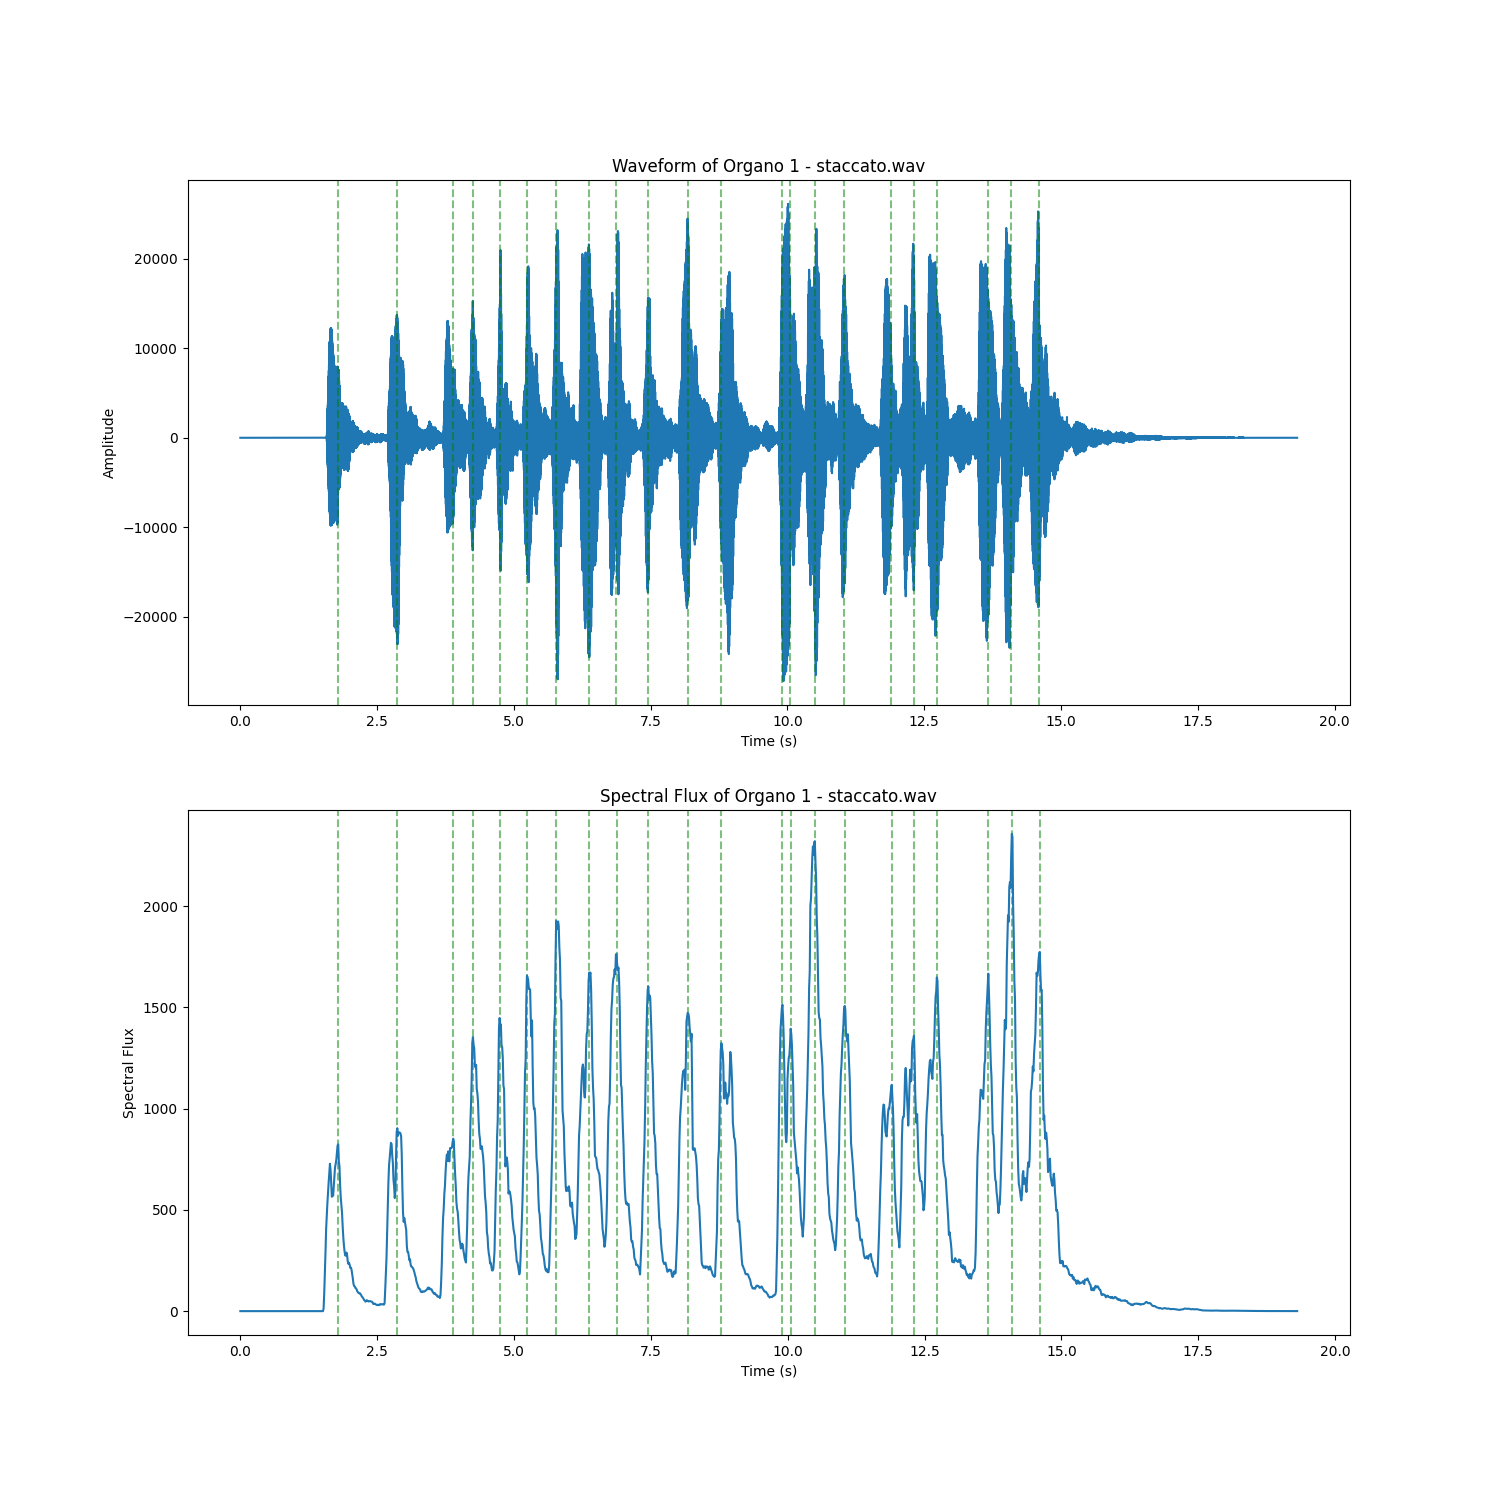

In [ ]:
file_select = widgets.Dropdown(
    options=piano_files,
    description='Select file:',
    disabled=False,
)

window_size_slider = widgets.IntSlider(
    value=1024,
    min=256,
    max=8192,
    step=256,
    description='RMS Window Size:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

convolve_window_slider = widgets.IntSlider(
    value=10,
    min=1,
    max=1000,
    step=1,
    description='Convolve Window:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

def on_file_change(change):
    selected_file = change['new']
    fs, data = waveform_dict[selected_file]

    ch1 = data[:, 0]
    ch2 = data[:, 1]

    waveform_ax[0].clear()
    waveform_ax[0].plot(np.arange(len(data)) / fs, ch1, label='Channel 1')
    #waveform_ax[0].plot(np.arange(len(data)) / fs, ch2, label='Channel 2')
    waveform_ax[0].set_title(f"Waveform of {selected_file}")
    waveform_ax[0].set_xlabel("Time (s)")
    waveform_ax[0].set_ylabel("Amplitude")

    waveform_ax[1].clear()

    waveform_ax[1].clear()
    inds, spectral_flux = compute_spectral_flux(ch1, frame_size=1024, hop_size=512)
    smooth_flux = np.convolve(spectral_flux, np.ones(convolve_window_slider.value)/convolve_window_slider.value, mode='same')

    time_flux = inds / fs

    flux_peaks, _ = sp.signal.find_peaks(smooth_flux, prominence=500, distance=10)

    for peak in flux_peaks:
        waveform_ax[1].axvline(x=peak * (512 / fs), color='g', linestyle='--', alpha=0.5)
        waveform_ax[0].axvline(x=peak * (512 / fs), color='g', linestyle='--', alpha=0.5)

    waveform_ax[1].plot(time_flux, smooth_flux, label='Spectral Flux')
    waveform_ax[1].set_title(f"Spectral Flux of {selected_file}")
    waveform_ax[1].set_xlabel("Time (s)")
    waveform_ax[1].set_ylabel("Spectral Flux")

    waveform_fig.canvas.draw()

def update_plots(change):
    on_file_change({'new': file_select.value})

with plt.ioff():
    waveform_fig, waveform_ax = plt.subplots(figsize=(15, 15), nrows=2)

    waveform_ax[0].set_title("Waveform")
    waveform_ax[0].set_xlabel("Time (s)")
    waveform_ax[0].set_ylabel("Amplitude")
    waveform_ax[0].grid()

    waveform_ax[1].set_title("Spectral Flux")
    waveform_ax[1].set_xlabel("Time (s)")
    waveform_ax[1].set_ylabel("Spectral Flux")
    waveform_ax[1].grid()


display(file_select, window_size_slider, convolve_window_slider)
file_select.observe(on_file_change, names='value')
window_size_slider.observe(update_plots, names='value')
convolve_window_slider.observe(update_plots, names='value')
on_file_change({'new': file_select.value})  # Initialize with the first file
plt.show()


In [123]:
#filename = "Piano scala Mi - veloe legato.wav"
#filename = piano_files[0]  # Use the first file by default
filename = file_select.value  # Use the selected file from the dropdown

waveform = waveform_dict[filename][1]
fs = waveform_dict[filename][0]

ch1 = waveform[:, 0]
ch2 = waveform[:, 1]

frame_size = 1024
hop_size = 512

onsets = detect_onsets(ch1, fs)

print("Detected onsets (in seconds):", samples_to_secs(onsets, fs))

segments = segment_signal(ch1, fs, onsets)

Detected onsets (in seconds): [ 2.87927438  4.27247166  4.74848073  5.25931973  5.79337868  6.38548753
  6.8614966   7.46521542  8.18503401  8.78875283  9.8800907  10.03102041
 10.47219955 11.06430839 11.86539683 12.12081633 12.72453515 13.65333333
 14.07129252 14.58213152]


In [124]:
#def detect_onsets(rms, fs, threshold=40, min_distance_secs=0.5, window_size=1024, smoothing=1):
#    """Detect onsets in an RMS envelope."""
#    # Smooth the RMS envelope
#    if smoothing > 1:
#        rms = np.convolve(rms, np.ones(smoothing)/smoothing, mode='same')
#
#    # Normalize RMS to percentage
#    norm_rms = rms / np.max(rms) * 100
#
#    # Find peaks in the RMS envelope
#    peaks, _ = sp.signal.find_peaks(norm_rms, height=threshold, distance=secs_to_samples(min_distance_secs, fs))
#
#    return peaks, norm_rms
#
#filename = "Piano scala MI - veloce staccato.wav"
#
#waveform = waveform_dict[filename][1]
#fs = waveform_dict[filename][0]
#
#ch1 = waveform[:, 0]
#ch2 = waveform[:, 1]
#
#rms_ch1 = moving_rms(ch1, window_size=window_size_slider.value)
#rms_ch1 = np.concatenate((np.zeros(window_size_slider.value-1), rms_ch1))  # Pad to match original length
#rms_ch1 = np.nan_to_num(rms_ch1, nan=0.0, posinf=0.0, neginf=0.0)  # Remove infs and nans
#
#peaks, norm_rms_ch1 = detect_onsets(rms_ch1, fs, threshold=40, min_distance_secs=0.5, window_size=2048, smoothing=100)
#
#print(f"Detected onsets at: {samples_to_secs(peaks, fs)} seconds")

In [125]:
## cut the waveform into segments based on detected onsets
#segments = []
#peaks_with0 = np.concatenate(([0], peaks))  # Add start of the waveform as boundaries
#for i in range(len(peaks_with0)-1):
#    start_sample = peaks_with0[i]
#    end_sample = peaks_with0[i+1]
#    segment = ch1[start_sample:end_sample]
#    segments.append(segment)
#
#

In [126]:
def compute_avg_spectrum(segment, fs):
    width = (len(segment) / fs) / 10  # Set width to 1/10th of the segment duration
    gaussian_window = sp.signal.windows.gaussian(int(width * fs), std = 0.2 * fs)
    freqs, avg_spectrum = sp.signal.welch(segment, fs = fs, window = gaussian_window, nperseg = len(gaussian_window))
    return freqs, avg_spectrum

def compute_avg_spectrum_nperiods(segment, fs, n_periods=10):

    peaks, _ = sp.signal.find_peaks(segment, height=np.max(segment)*0.5)

    peaks_diff = np.diff(peaks)
    if len(peaks_diff) == 0:
        return None, None  # Not enough peaks to compute periods
    
    period = np.median(peaks_diff)  # Estimate period as median distance between peaks
    segment_length = len(segment)
    n_samples_per_period = int(period)
    n_samples_to_use = n_samples_per_period * n_periods

    window = sp.signal.windows.gaussian(n_samples_to_use, std=0.2 * n_samples_to_use)

    freqs, avg_spectrum = sp.signal.welch(segment, fs=fs, window=window, nperseg=len(window))

    return freqs, avg_spectrum


# compute power spectrum for each segment
power_spectra = []
for segment in segments:
    try:
        freqs, psd = compute_avg_spectrum_nperiods(segment, fs, n_periods=20)
        power_spectra.append((freqs, psd))
    except Exception as e:
        print(f"Error processing segment: {e}")

Error processing segment: zero-size array to reduction operation maximum which has no identity
Error processing segment: Invalid Parameter p0=0, p1=0, i.e., self.p_min=0 <= p0 < p1 <= p_max=3 does not hold for signal length n=2444!


In [127]:
def cleanup_segments(segments, fs, min_duration_secs=0.1, window_size=2048):
    """
    Cut each segment again, to remove small amplitude tails at the beginning and end of each segment.
    """
    for i in range(len(segments)):
        try:
            segment = segments[i]
            
            segment_peaks, _ = sp.signal.find_peaks(segment, height=np.max(segment)*0.1)

            if len(segment_peaks) == 0:
                segments[i] = None  # Mark for removal
                continue

            start_sample = segment_peaks[0]
            end_sample = segment_peaks[-1]

            segments[i] = segment[start_sample:end_sample]
        except Exception as e:
            print(f"Error cleaning segment {i}: {e}")
            segments[i] = None  # Mark for removal
    
    # Remove segments that are too short
    segments = [seg for seg in segments if seg is not None]
    return segments

In [128]:
segments = cleanup_segments(segments, fs, min_duration_secs=0.1, window_size=2048)

Error cleaning segment 10: zero-size array to reduction operation maximum which has no identity


In [129]:
avg_amplitudes = np.array([np.mean(np.abs(seg)) for seg in segments])

avg_amplitude = np.mean(avg_amplitudes)

filtered_segments = [seg for seg in segments if np.mean(np.abs(seg)) > avg_amplitude * 0.5]


In [130]:
def find_peaks(segment_psd, freqs, prominence=5, height=0, distance=10):

    spectrum = np.log10(segment_psd)

    # remove infs and nans
    spectrum = np.nan_to_num(spectrum, nan=0.0, posinf=0.0, neginf=0.0)

    norm_spectrum = spectrum / np.max(spectrum) * 100  # Normalize to percentage

    peaks_params = {
        "prominence": prominence,
        "height": height,
        "distance": distance
    }

    peaks, _ = sp.signal.find_peaks(norm_spectrum, **peaks_params)


    return freqs[peaks]

In [131]:
spectrum_peaks = []
for i, (freqs, psd) in enumerate(power_spectra):
    
    spectrum_peaks.append(find_peaks(psd, freqs, prominence=20, height=0, distance=10))

    print(f"Segment {i+1}: Detected peaks at frequencies: {spectrum_peaks[-1]} Hz")

Segment 1: Detected peaks at frequencies: [ 441.  882. 1323. 1764. 2646. 3528. 5292.] Hz
Segment 2: Detected peaks at frequencies: [ 389.11764706  778.23529412 1167.35294118 1556.47058824 2360.64705882
 3138.88235294] Hz
Segment 3: Detected peaks at frequencies: [ 356.36363636  690.45454545 1046.81818182 1403.18181818 1759.54545455
 2093.63636364 2784.09090909] Hz
Segment 4: Detected peaks at frequencies: [ 331.57894737  663.15789474  994.73684211 1326.31578947 1575.
 1757.36842105 1972.89473684 2652.63157895] Hz
Segment 5: Detected peaks at frequencies: [ 264.07185629  594.16167665  792.21556886  990.26946108 1175.11976048
 1320.35928144 1571.22754491 1756.07784431 1914.52095808 2086.16766467
 2350.23952096 3142.45508982 3525.35928144 4172.33532934] Hz
Segment 6: Detected peaks at frequencies: [ 262.13286713  524.26573427  786.3986014  1048.53146853 1310.66433566
 1495.6993007  1834.93006993 2097.06293706 2975.97902098 3145.59440559] Hz
Segment 7: Detected peaks at frequencies: [ 253.

Dropdown(description='Select segment:', options=('Segment 1', 'Segment 2', 'Segment 3', 'Segment 4', 'Segment …

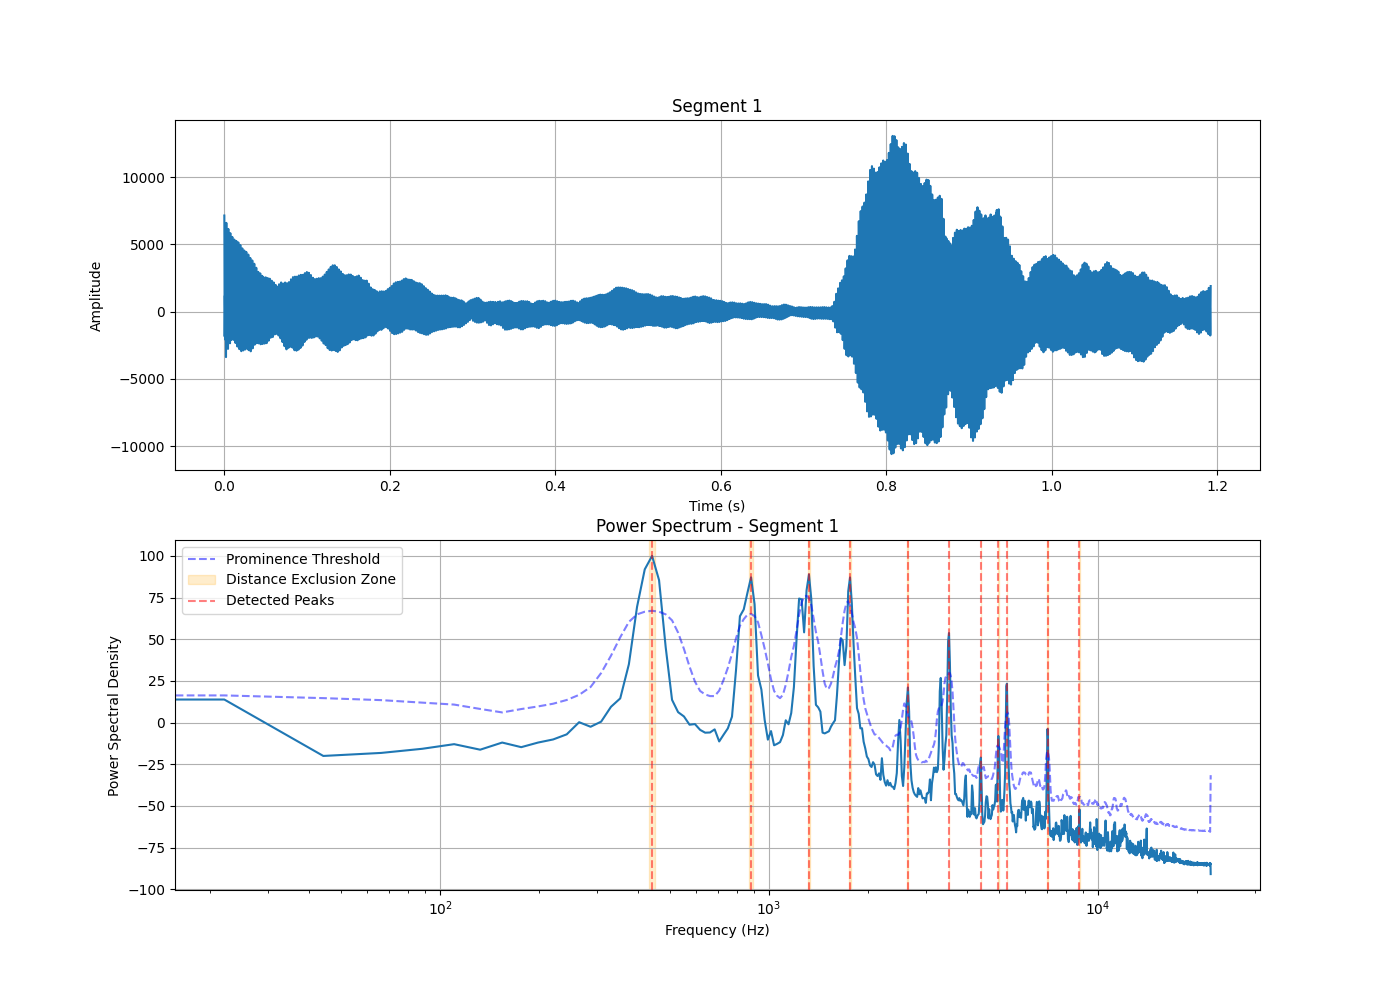

In [132]:
segment_select = widgets.Dropdown(
    options=[f"Segment {i+1}" for i in range(len(segments))],
    description='Select segment:',
    disabled=False,
)

with plt.ioff():
    segment_fig, segment_ax = plt.subplots(figsize=(14, 10), nrows=2)
    segment_ax[0].set_title("Selected Segment")
    segment_ax[0].set_xlabel("Time (s)")
    segment_ax[0].set_ylabel("Amplitude")
    segment_ax[0].grid()

    segment_ax[1].set_title("Power Spectrum")
    segment_ax[1].set_xlabel("Frequency (Hz)")
    segment_ax[1].set_ylabel("Power Spectral Density")
    segment_ax[1].grid()

def on_segment_change(change):
    selected_segment = change['new']
    index = int(selected_segment.split()[1]) - 1
    segment = segments[index]

    segment_ax[0].clear()
    segment_ax[0].plot(np.arange(len(segment)) / fs, segment)
    segment_ax[0].set_title(f"Segment {index+1}")
    segment_ax[0].set_xlabel("Time (s)")
    segment_ax[0].set_ylabel("Amplitude")
    segment_ax[0].grid()

    segment_psd = power_spectra[index][1]

    spectrum = segment_psd
    spectrum = np.log10(segment_psd)

    # remove infs and nans
    spectrum = np.nan_to_num(spectrum, nan=0.0, posinf=0.0, neginf=0.0)

    norm_spectrum = spectrum / np.max(spectrum) * 100  # Normalize to percentage

    segment_ax[1].clear()
    segment_ax[1].plot(power_spectra[index][0], norm_spectrum)
    segment_ax[1].set_title(f"Power Spectrum - Segment {index+1}")
    segment_ax[1].set_xlabel("Frequency (Hz)")
    segment_ax[1].set_ylabel("Power Spectral Density")
    segment_ax[1].set_xscale('log')
    #segment_ax[1].set_yscale('log')
    segment_ax[1].grid()

    peaks_params = {
        #"prominence": 100,
        "prominence": 20,
        "distance": 10
    }

    if "height" in peaks_params:
        segment_ax[1].axhline(y=peaks_params["height"], color='g', linestyle='--', alpha=0.5, label='Height Threshold')
    
    if "prominence" in peaks_params:
        y_moving_avg = sp.signal.convolve(norm_spectrum, np.ones(10)/10, mode='same')
        y_plus_prominence = y_moving_avg + peaks_params["prominence"]
        segment_ax[1].plot(power_spectra[index][0], y_plus_prominence, color='b', linestyle='--', alpha=0.5, label='Prominence Threshold')        
    
    peaks, _ = sp.signal.find_peaks(norm_spectrum, **peaks_params)

    if "distance" in peaks_params:
        for peak in peaks:
            x1 = power_spectra[index][0][peak] - peaks_params["distance"]
            x2 = power_spectra[index][0][peak] + peaks_params["distance"]
            segment_ax[1].axvspan(x1, x2, color='orange', alpha=0.2, label='Distance Exclusion Zone' if peak == peaks[0] else "")


    for peak in peaks:
        segment_ax[1].axvline(x=power_spectra[index][0][peak], color='r', linestyle='--', alpha=0.5, label='Detected Peaks' if peak == peaks[0] else "")
    
    segment_ax[1].legend()

    segment_fig.canvas.draw()

segment_select.observe(on_segment_change, names='value')
display(segment_select)
on_segment_change({'new': segment_select.value})  # Initialize with the first segment
plt.show()

In [133]:
from numpy.strings import index


def get_f0_first_peak(peak_freqs, freqs, spectrum):
    return peak_freqs[0] if len(peak_freqs) > 0 else None


def get_f0_from_gcd(peak_freqs):

    if len(peak_freqs) < 2:
        return None

    peak_freqs = np.sort(peak_freqs)[:6]

    reference_peak = peak_freqs[0]

    best_f0 = reference_peak
    best_score = float('inf')

    for n in range(1, 7):
        f0_candidate = reference_peak / n
        
        residuals = [np.abs(f / f0_candidate - round(f / f0_candidate)) for f in peak_freqs]
        
        avg_error = np.mean(residuals)

        if avg_error < 0.05:
            return f0_candidate

        if avg_error < best_score:
            best_score = avg_error
            best_f0 = f0_candidate
            
    return best_f0

def get_f0_gcd_mag_aware(peak_freqs, psd):

    f0_candidate = get_f0_from_gcd(peak_freqs)

    best_f0 = f0_candidate
    best_mag = psd[np.argmin(np.abs(freqs - f0_candidate))]

    for n in range(1, 20):

        f = f0_candidate * n

        if f > freqs[-1]:
            break

        idx = np.argmin(np.abs(freqs - f))
        mag = psd[idx]
        if mag > best_mag:
            best_mag = mag
            best_f0 = f0_candidate
    
    return best_f0

def get_f0_linear_regression(peak_freqs, peak_mags):

    if len(peak_freqs) < 2 or len(peak_mags) < 2:
        return None

    top_indices = np.argsort(peak_mags)[-6:]
    top_freqs = np.sort(peak_freqs[top_indices]) 

    rough_f0 = top_freqs[0]

    x = np.round(top_freqs / rough_f0)
    y = top_freqs

    valid = x > 0
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return rough_f0

    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0] 
    
    return m  

In [134]:
def get_limiti_prior(observed_freqs):

    f_min = np.min(observed_freqs) * 0.5
    f_max = np.min(observed_freqs) * 3

    log_sigma_min = np.log(0.1)
    log_sigma_max = np.log(100)

    log_uniform = -np.log(f_max - f_min)

    return f_min, f_max, log_sigma_min, log_sigma_max, log_uniform

def compute_P_n_log_magnitude_aware(peak_freqs, peak_mags, ns, alpha=0.6, eps=1e-8):

    ns = np.asarray(ns)
    peak_freqs = np.asarray(peak_freqs)
    peak_mags = np.asarray(peak_mags)
   
    f0_guess = float(peak_freqs[0])

    env = np.zeros_like(ns, dtype=float)
    for fk, mk in zip(peak_freqs, peak_mags):
        if fk <= 0 or mk <= 0:
            continue
        n_est = int(np.round(fk / f0_guess))
        if 1 <= n_est <= ns[-1]:
            env[n_est - 1] += mk

    weights = (env + eps) * np.exp(-alpha * (ns - 1).astype(float))
    weights = weights / np.sum(weights)

    return np.log(weights)

def get_f0_bayesian_map(peak_freqs, peak_mags):

    f_min, f_max, log_sigma_min, log_sigma_max, log_uniform = get_limiti_prior(peak_freqs)

    # Parametri delle armoniche
    ns = np.arange(1, 21)   # Consideriamo le prime 20 armoniche
    P_n_log = compute_P_n_log_magnitude_aware(peak_freqs, peak_mags, np.arange(1,21))
    U_log = log_uniform # Probabilità uniforme del rumore
    q_min = 0
    q_max = 1

    def log_prob(theta):

        f0, log_sigma, q = theta
        sigma = np.exp(log_sigma)

        if not (f_min < f0 < f_max and log_sigma_min < log_sigma < log_sigma_max and q_min < q < q_max):
            return -1e15

        total_log_likelihood = 0.0

        for fk in peak_freqs:

            log_gaussians = -0.5 * ((fk - ns * f0) / sigma)**2 - log_sigma - 0.5 * np.log(2 * np.pi)
            
            log_p_harmonics = logsumexp(log_gaussians + P_n_log)

            log_p_total = np.logaddexp(np.log(q) + log_p_harmonics, np.log(1 - q) + U_log)
            
            total_log_likelihood += log_p_total

        return total_log_likelihood

    f_start = float(peak_freqs[0])  

    sigma_start = np.log(0.1*f_start)  

    q_start = 0.8

    x0 = [f_start, sigma_start, q_start]

    res = sp.optimize.minimize(
        lambda t: -log_prob(t),
        x0=x0,
        method='L-BFGS-B',
        bounds=[
            (f_min, f_max),
            (log_sigma_min, log_sigma_max),
            (q_min, q_max)
        ],
        options={'maxiter': 300}
    )

    f0_map, log_sigma_map, q_map = res.x
    q_map = float(np.clip(q_map, q_min, q_max))
    print(f"MAP Singolo -> F0: {f0_map:.2f}Hz, Sigma: {np.exp(log_sigma_map):.5f}Hz, q: {q_map:.8f}")

    return f0_map, q_map

In [135]:
def get_best_f0_multiple(f0, peak_freqs, psd):
    
    best_f0 = f0
    best_mag = psd[np.argmin(np.abs(freqs - f0))]

    for n in range(1, 20):

        f = f0 * n

        if f > freqs[-1]:
            break

        idx = np.argmin(np.abs(freqs - f))
        mag = psd[idx]
        if mag > best_mag:
            best_mag = mag
            best_f0 = f0
    
    return best_f0

In [136]:
from math import floor


def get_limiti_prior_new(observed_freqs):

    f_min = np.min(observed_freqs) * 0.7
    f_max = np.min(observed_freqs) * 3

    log_sigma_min = np.log(0.1)
    log_sigma_max = np.log(100)

    return f_min, f_max, log_sigma_min, log_sigma_max

def f0_bayes_prior(f0, sigma, q, f_min, f_max, log_sigma_min, log_sigma_max):
    """
    Computes the log-prior probability of the model parameters (f0, sigma, q) based on the defined prior distributions.
     - f0 is assumed to have a gaussian prior centered around the first observed peak frequency with a standard deviation of 20% of that frequency.
     - sigma is assumed to have a uniform prior in log-space between log_sigma_min and log_sigma_max.
     - q is assumed to have a uniform prior between 0 and 1.
     The function returns the sum of the log-priors for all parameters.
    """

    if not (f_min < f0 < f_max):
        return -np.inf  # Log-prior is very low if f0 is out of bounds

    if not (log_sigma_min < np.log(sigma) < log_sigma_max):
        return -np.inf  # Log-prior is very low if sigma is out of bounds

    if not (0 < q < 1):
        return -np.inf  # Log-prior is very low if q is out of bounds

    log_prior_f0 = -0.5 * ((f0 - f_min) / (0.2 * f_min))**2 - np.log(0.2 * f_min) - 0.5 * np.log(2 * np.pi)  # Gaussian prior
    log_prior_sigma = -np.log(log_sigma_max - log_sigma_min) - np.log(sigma)  # Uniform in log-space
    log_prior_q = 0  # Uniform between 0 and 1

    return log_prior_f0 + log_prior_sigma + log_prior_q


def f0_bayes_likelihood(f0, sigma, q, peak_freqs, peak_mags, f_min, f_max):
    """
    Compute the log-likelihood of the observed peaks given the model parameters.
    The model assumes peaks are either harmonics of the fundamental frequency (with probability q) or noise (with probability 1-q).
    For harmonics, the expected frequencies are n*f0 with a Gaussian spread defined by sigma. The likelihood is computed in log-space for numerical stability.
    The indices are considered latent variables and marginalized out by summing over all possible n values.
    For noise, we assume a uniform distribution over the frequency range of interest, which contributes a constant log-likelihood.
    """

    ns = np.arange(1, len(peak_freqs) + 1)  # Consideriamo fino a N armoniche, dove N è il numero di picchi osservati
    #P_n_log = compute_P_n_log_magnitude_aware(peak_freqs, peak_mags, ns)

    # prior gaussiano per il numero di armoniche, centrato su len(peak_freqs) * q con deviazione standard di 2 armoniche
    P_n_log = -0.5 * ((ns - len(peak_freqs) * q) / 2)**2 - np.log(2) - 0.5 * np.log(2 * np.pi)

    U_log = np.log(1 / (f_max - f_min))  # Probabilità uniforme del rumore

    total_log_likelihood = 0.0

    for fk in peak_freqs:

        log_gaussians = -0.5 * ((fk - ns * f0) / sigma)**2 - np.log(sigma) - 0.5 * np.log(2 * np.pi)
        
        log_p_harmonics = logsumexp(log_gaussians + P_n_log)

        log_p_total = np.logaddexp(np.log(q) + log_p_harmonics, np.log(1 - q) + U_log)
        
        total_log_likelihood += log_p_total

    return total_log_likelihood



def f0_bayes_posterior(f0, sigma, q, peak_freqs, peak_mags, f_min, f_max, log_sigma_min, log_sigma_max):
    """
    Computes the probability of the model parameters (f0, sigma, q) given the observed data (peak frequencies and magnitudes) using Bayes' theorem.
    """

    log_prior = f0_bayes_prior(f0, sigma, q, f_min, f_max, log_sigma_min, log_sigma_max)
    if log_prior == -np.inf:
        return -np.inf  # If the prior is zero, the posterior is zero

    log_likelihood = f0_bayes_likelihood(f0, sigma, q, peak_freqs, peak_mags, f_min, f_max)

    return log_prior + log_likelihood

def run_mcmc(peak_freqs, peak_mags, f_min, f_max, log_sigma_min, log_sigma_max, n_walkers=50, n_steps=500):

    def log_prob(theta):
        f0, log_sigma, q = theta
        sigma = np.exp(log_sigma)
        return f0_bayes_posterior(f0, sigma, q, peak_freqs, peak_mags, f_min, f_max, log_sigma_min, log_sigma_max)

    initial_f0 = float(peak_freqs[0])
    initial_log_sigma = np.log(0.1 * initial_f0)
    initial_q = 0.8

    initial_pos = []
    for _ in range(n_walkers):
        f0_sample = np.random.uniform(f_min, f_max)
        log_sigma_sample = np.random.uniform(log_sigma_min, log_sigma_max)
        q_sample = np.random.uniform(0, 1)
        initial_pos.append([f0_sample, log_sigma_sample, q_sample])

    sampler = emcee.EnsembleSampler(n_walkers, 3, log_prob)

    sampler.run_mcmc(initial_pos, n_steps, progress=True)

    samples = sampler.get_chain(discard=int(n_steps/2), flat=True)

    return samples
    


In [137]:
f0s_dict = {
    "first_peak" : [],
    "gcd" : [],
    "magnitude aware gcd" : [],
    "linear_regression" : [],
    "bayesian_map" : [],
    #"bayes mcmc" : []
}

In [138]:
qs = []
qs_mcmcm = []

for freqs, psd in power_spectra:
    peak_freqs = find_peaks(psd, freqs, prominence=20, height=-200, distance=10)
    peaks_mags = psd[np.searchsorted(freqs, peak_freqs)]


    f0s_dict["first_peak"].append(get_f0_first_peak(peak_freqs, freqs, psd))

    f0s_dict["gcd"].append(get_f0_from_gcd(peak_freqs))

    f0s_dict["magnitude aware gcd"].append(get_f0_gcd_mag_aware(peak_freqs, psd))

    f0s_dict["linear_regression"].append(get_f0_linear_regression(peak_freqs, peaks_mags))

    f0_map, q_map = get_f0_bayesian_map(peak_freqs, peaks_mags)
    f0s_dict["bayesian_map"].append(f0_map)
    qs.append(q_map)

    #f_min, f_max, log_sigma_min, log_sigma_max = get_limiti_prior_new(peak_freqs)
    #samples = run_mcmc(peak_freqs, peaks_mags, f_min, f_max, log_sigma_min, log_sigma_max, n_walkers=50, n_steps=100)
    #f0s_dict["bayes mcmc"].append(np.median(samples[:, 0]))
    #qs_mcmcm.append(np.median(samples[:, 2]))


MAP Singolo -> F0: 441.00Hz, Sigma: 0.10000Hz, q: 0.37748134
MAP Singolo -> F0: 389.12Hz, Sigma: 0.10000Hz, q: 0.39607023
MAP Singolo -> F0: 356.36Hz, Sigma: 0.10000Hz, q: 0.09063004
MAP Singolo -> F0: 331.58Hz, Sigma: 0.10000Hz, q: 0.38867651
MAP Singolo -> F0: 264.07Hz, Sigma: 0.10000Hz, q: 0.04411950
MAP Singolo -> F0: 262.13Hz, Sigma: 0.10000Hz, q: 0.09746456
MAP Singolo -> F0: 253.81Hz, Sigma: 0.10000Hz, q: 0.06626504
MAP Singolo -> F0: 342.40Hz, Sigma: 9.21645Hz, q: 0.00000008
MAP Singolo -> F0: 325.96Hz, Sigma: 0.10000Hz, q: 0.09062269
MAP Singolo -> F0: 162.47Hz, Sigma: 0.10000Hz, q: 0.12330940
MAP Singolo -> F0: 190.70Hz, Sigma: 0.10000Hz, q: 0.07642309
MAP Singolo -> F0: 41.41Hz, Sigma: 0.10000Hz, q: 0.04792562
MAP Singolo -> F0: 237.46Hz, Sigma: 0.10000Hz, q: 0.09950488
MAP Singolo -> F0: 247.90Hz, Sigma: 0.10000Hz, q: 0.24395022
MAP Singolo -> F0: 262.50Hz, Sigma: 0.10000Hz, q: 0.17765939
MAP Singolo -> F0: 268.16Hz, Sigma: 0.10184Hz, q: 0.20617651
MAP Singolo -> F0: 252.48

In [139]:
print("\nEstimated F0s for each segment:")
for i in range(len(power_spectra)):
    print(f"Segment {i+1}, number of peaks: {len(peak_freqs)}")
    print(f"  First Peak: {f0s_dict['first_peak'][i]:.2f} Hz")
    print(f"  GCD Method: {f0s_dict['gcd'][i]:.2f} Hz")
    print(f"  Magnitude-Aware GCD: {f0s_dict['magnitude aware gcd'][i]:.2f} Hz")
    print(f"  Linear Regression: {f0s_dict['linear_regression'][i]:.2f} Hz")
    print(f"  Bayesian MAP: {f0s_dict['bayesian_map'][i]:.2f} Hz, q: {qs[i]:.8f}")
    #print(f"  Bayesian MCMC: {f0s_dict['bayes mcmc'][i]:.2f} Hz, q: {qs_mcmcm[i]:.8f}")


Estimated F0s for each segment:
Segment 1, number of peaks: 19
  First Peak: 441.00 Hz
  GCD Method: 441.00 Hz
  Magnitude-Aware GCD: 441.00 Hz
  Linear Regression: 441.00 Hz
  Bayesian MAP: 441.00 Hz, q: 0.37748134
Segment 2, number of peaks: 19
  First Peak: 389.12 Hz
  GCD Method: 389.12 Hz
  Magnitude-Aware GCD: 389.12 Hz
  Linear Regression: 393.70 Hz
  Bayesian MAP: 389.12 Hz, q: 0.39607023
Segment 3, number of peaks: 19
  First Peak: 356.36 Hz
  GCD Method: 356.36 Hz
  Magnitude-Aware GCD: 356.36 Hz
  Linear Regression: 348.30 Hz
  Bayesian MAP: 356.36 Hz, q: 0.09063004
Segment 4, number of peaks: 19
  First Peak: 331.58 Hz
  GCD Method: 82.89 Hz
  Magnitude-Aware GCD: 82.89 Hz
  Linear Regression: 328.44 Hz
  Bayesian MAP: 331.58 Hz, q: 0.38867651
Segment 5, number of peaks: 19
  First Peak: 264.07 Hz
  GCD Method: 66.02 Hz
  Magnitude-Aware GCD: 66.02 Hz
  Linear Regression: 257.02 Hz
  Bayesian MAP: 264.07 Hz, q: 0.04411950
Segment 6, number of peaks: 19
  First Peak: 262.13

In [140]:
t = f0s_dict["bayesian_map"]

converted = get_best_f0_multiple(t[0], freqs, psd)

f0s_dict["bayesian_map"][0] = converted

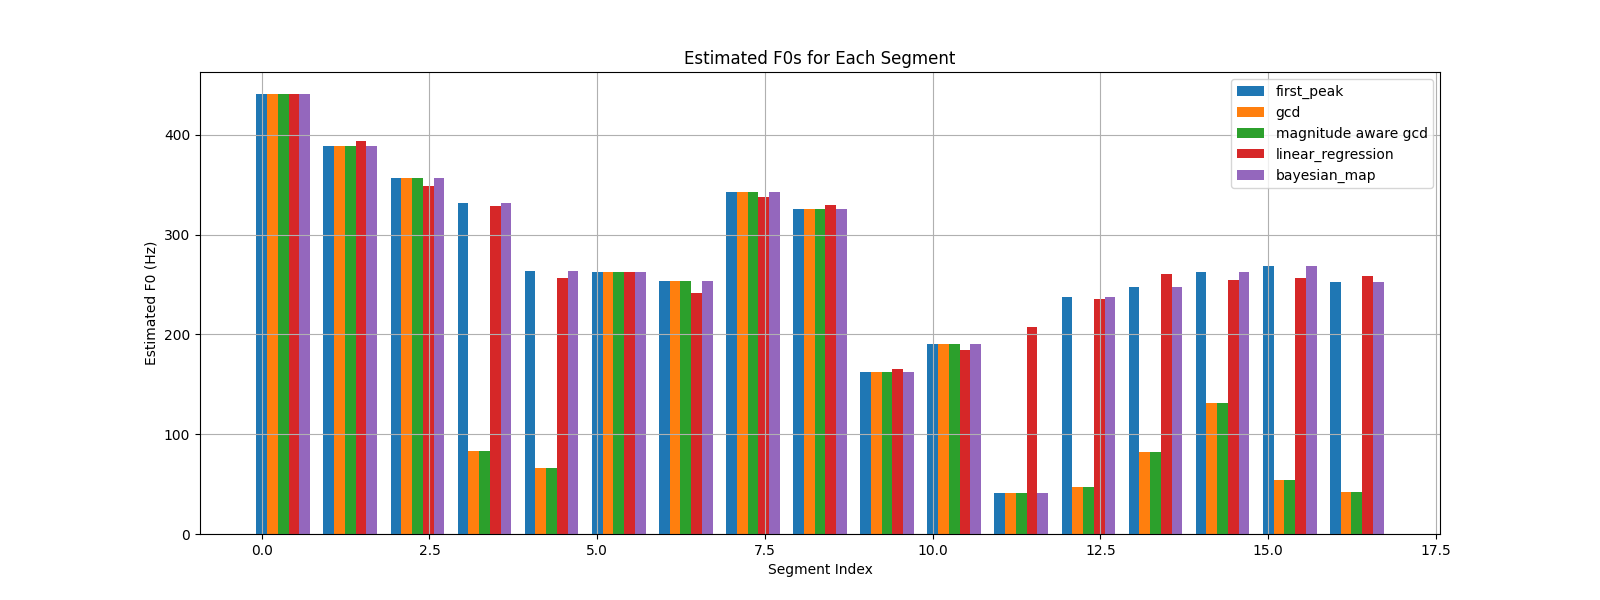

In [141]:
plt.figure(figsize=(16, 6))

for method, f0s in f0s_dict.items():
    method_idx = list(f0s_dict.keys()).index(method)

    xs = np.arange(len(f0s)) + method_idx * 0.8 / len(f0s_dict)

    plt.bar(height=f0s, x=xs, label=method, width=0.8 / len(f0s_dict))

plt.title("Estimated F0s for Each Segment")
plt.xlabel("Segment Index")
plt.ylabel("Estimated F0 (Hz)")
plt.legend()
plt.grid()
plt.show()

In [142]:
note_freqs = {}
for octave in range(1, 7):  # 1..8
    for i, note in enumerate(["DO", "DO#", "RE", "RE#", "MI", "FA", "FA#", "SOL", "SOL#", "LA", "LA#", "SI"]):
        freq = 16.35 * (2 ** octave) * (2 ** (i / 12))
        note_freqs[f"{note}{octave}"] = freq

def find_closest_note(freq, note_freqs):
    closest_note = None
    min_diff = float('inf')
    for note, note_freq in note_freqs.items():
        diff = abs(freq - note_freq)
        if diff < min_diff:
            min_diff = diff
            closest_note = note
    return closest_note

print("Frequenze delle note:")
for note, freq in sorted(note_freqs.items()):
    print(f"  {note}: {freq:.2f} Hz")

Frequenze delle note:
  DO#1: 34.64 Hz
  DO#2: 69.29 Hz
  DO#3: 138.58 Hz
  DO#4: 277.16 Hz
  DO#5: 554.31 Hz
  DO#6: 1108.62 Hz
  DO1: 32.70 Hz
  DO2: 65.40 Hz
  DO3: 130.80 Hz
  DO4: 261.60 Hz
  DO5: 523.20 Hz
  DO6: 1046.40 Hz
  FA#1: 46.24 Hz
  FA#2: 92.49 Hz
  FA#3: 184.98 Hz
  FA#4: 369.96 Hz
  FA#5: 739.92 Hz
  FA#6: 1479.83 Hz
  FA1: 43.65 Hz
  FA2: 87.30 Hz
  FA3: 174.60 Hz
  FA4: 349.19 Hz
  FA5: 698.39 Hz
  FA6: 1396.78 Hz
  LA#1: 58.26 Hz
  LA#2: 116.53 Hz
  LA#3: 233.06 Hz
  LA#4: 466.12 Hz
  LA#5: 932.24 Hz
  LA#6: 1864.47 Hz
  LA1: 54.99 Hz
  LA2: 109.99 Hz
  LA3: 219.98 Hz
  LA4: 439.96 Hz
  LA5: 879.91 Hz
  LA6: 1759.83 Hz
  MI1: 41.20 Hz
  MI2: 82.40 Hz
  MI3: 164.80 Hz
  MI4: 329.60 Hz
  MI5: 659.19 Hz
  MI6: 1318.38 Hz
  RE#1: 38.89 Hz
  RE#2: 77.77 Hz
  RE#3: 155.55 Hz
  RE#4: 311.10 Hz
  RE#5: 622.19 Hz
  RE#6: 1244.39 Hz
  RE1: 36.70 Hz
  RE2: 73.41 Hz
  RE3: 146.82 Hz
  RE4: 293.64 Hz
  RE5: 587.27 Hz
  RE6: 1174.54 Hz
  SI1: 61.73 Hz
  SI2: 123.46 Hz
  SI3: 246

In [143]:
bayesian_f0s = f0s_dict["bayesian_map"]

print("\nEstimated notes for each segment (Bayesian MAP):")
for i, f0 in enumerate(bayesian_f0s):
    closest_note = find_closest_note(f0, note_freqs)
    print(f"Segment {i+1}: Estimated F0 = {f0:.2f} Hz, Closest Note = {closest_note}")



Estimated notes for each segment (Bayesian MAP):
Segment 1: Estimated F0 = 441.00 Hz, Closest Note = LA4
Segment 2: Estimated F0 = 389.12 Hz, Closest Note = SOL4
Segment 3: Estimated F0 = 356.36 Hz, Closest Note = FA4
Segment 4: Estimated F0 = 331.58 Hz, Closest Note = MI4
Segment 5: Estimated F0 = 264.07 Hz, Closest Note = DO4
Segment 6: Estimated F0 = 262.13 Hz, Closest Note = DO4
Segment 7: Estimated F0 = 253.81 Hz, Closest Note = SI3
Segment 8: Estimated F0 = 342.40 Hz, Closest Note = FA4
Segment 9: Estimated F0 = 325.96 Hz, Closest Note = MI4
Segment 10: Estimated F0 = 162.47 Hz, Closest Note = MI3
Segment 11: Estimated F0 = 190.70 Hz, Closest Note = SOL3
Segment 12: Estimated F0 = 41.41 Hz, Closest Note = MI1
Segment 13: Estimated F0 = 237.46 Hz, Closest Note = LA#3
Segment 14: Estimated F0 = 247.90 Hz, Closest Note = SI3
Segment 15: Estimated F0 = 262.50 Hz, Closest Note = DO4
Segment 16: Estimated F0 = 268.16 Hz, Closest Note = DO4
Segment 17: Estimated F0 = 252.48 Hz, Closest

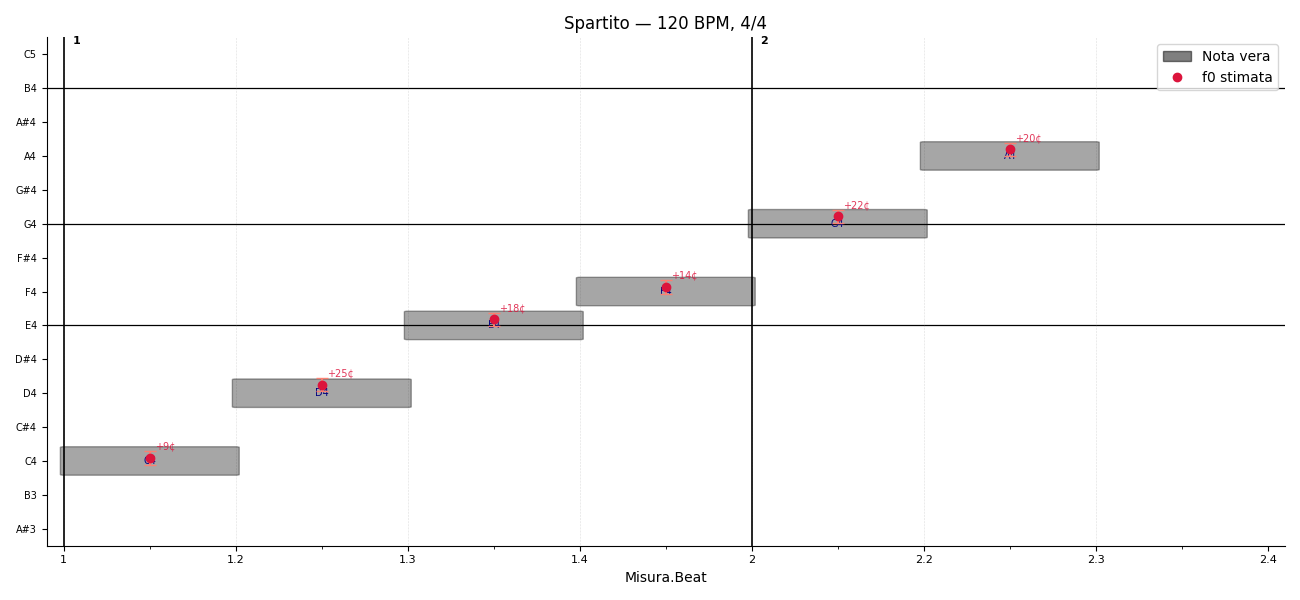

In [144]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

bpm = 120
beats_per_measure = 4

def seconds_to_beats(t, bpm):
    return t * bpm / 60

def freq_to_midi(f):
    return 12 * np.log2(f / 440.0) + 69

def midi_to_name(m):
    names = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
    m = int(round(m))
    return f"{names[m % 12]}{m // 12 - 1}"

# --- Dati (sostituisci con i tuoi) ---
onset_times  = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
offset_times = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
f0_estimated = np.array([263, 298, 333, 352, 397, 445])
f0_true      = np.array([261.63, 293.66, 329.63, 349.23, 392.00, 440.00])

# Converti tempi in beats
onset_beats  = seconds_to_beats(onset_times,  bpm)
offset_beats = seconds_to_beats(offset_times, bpm)
center_beats = (onset_beats + offset_beats) / 2

midi_est  = freq_to_midi(f0_estimated)
midi_true = freq_to_midi(f0_true)
midi_min  = int(np.floor(min(midi_true.min(), midi_est.min()))) - 2
midi_max  = int(np.ceil( max(midi_true.max(), midi_est.max()))) + 2

staff_lines_midi = [64, 67, 71, 74, 77]  # E4 G4 B4 D5 F5 (chiave di violino)

fig, ax = plt.subplots(figsize=(13, 6))

# --- Righe del pentagramma ---
for m in staff_lines_midi:
    ax.axhline(m, color='black', lw=0.9, zorder=1)

# --- Barre di misura ---
total_beats = offset_beats[-1] + 1
for beat in np.arange(0, total_beats, beats_per_measure):
    ax.axvline(beat, color='black', lw=1.2, zorder=2)

# --- Griglia sui quarti (linee leggere) ---
for beat in np.arange(0, total_beats, 1):
    ax.axvline(beat, color='gray', lw=0.4, ls=':', zorder=1, alpha=0.5)

# --- Note vere ---
for t_on, t_off, m in zip(onset_beats, offset_beats, midi_true):
    rect = mpatches.FancyBboxPatch(
        (t_on, m - 0.4), t_off - t_on, 0.8,
        boxstyle="round,pad=0.02",
        facecolor='black', edgecolor='black',
        alpha=0.35, zorder=3
    )
    ax.add_patch(rect)
    ax.text((t_on + t_off)/2, m, midi_to_name(m),
            ha='center', va='center', fontsize=7, color='navy', zorder=4)

# --- f0 stimate ---
ax.errorbar(
    center_beats, midi_est,
    yerr=0.2,
    fmt='o', color='crimson', ecolor='salmon',
    capsize=4, markersize=6, zorder=5, label='f0 stimata'
)

# Annotazioni centesimi
for cb, m_e, m_t in zip(center_beats, midi_est, midi_true):
    cents = (m_e - m_t) * 100
    ax.annotate(f"{cents:+.0f}¢", xy=(cb, m_e),
                xytext=(4, 6), textcoords='offset points',
                fontsize=7, color='crimson', alpha=0.85)

# --- Asse X: etichette misure e battiti ---
total_beats_int = int(np.ceil(total_beats))
beat_positions = np.arange(0, total_beats_int + 1, 1)
ax.set_xticks(beat_positions)

# Etichetta: "M2.3" = misura 2, beat 3
def beat_label(b, bpm_=beats_per_measure):
    measure = int(b // bpm_) + 1
    beat_in = int(b % bpm_) + 1
    return f"{measure}.{beat_in}" if beat_in > 1 else f"{measure}"

ax.set_xticklabels([beat_label(b) for b in beat_positions], fontsize=8)
ax.set_xlabel("Misura.Beat")
ax.xaxis.set_minor_locator(MultipleLocator(0.5))  # suddivisione alle crome

# --- Asse Y ---
midi_ticks = np.arange(midi_min, midi_max + 1)
ax.set_yticks(midi_ticks)
ax.set_yticklabels([midi_to_name(m) for m in midi_ticks], fontsize=7)
ax.set_ylim(midi_min - 0.5, midi_max + 0.5)
ax.set_xlim(-0.1, total_beats + 0.1)

# --- Numero di misura sopra le barre ---
for i, beat in enumerate(np.arange(0, total_beats, beats_per_measure)):
    ax.text(beat + 0.05, midi_max + 0.3, f"{i+1}",
            fontsize=8, fontweight='bold', color='black')

# --- Legenda ---
note_patch = mpatches.Patch(facecolor='black', edgecolor='black',
                             alpha=0.5, label='Nota vera')
est_line   = plt.Line2D([0],[0], marker='o', color='crimson',
                         ls='', label='f0 stimata')
ax.legend(handles=[note_patch, est_line], loc='upper right')
ax.set_title(f"Spartito — {bpm} BPM, {beats_per_measure}/4")
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()